In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load EMG CSV file
data = pd.read_csv("session_001.csv")

# Display the first 5 rows
print(data.head())

# Check the columns
print(data.columns)

# Check dimensions
print(data.shape)

      timestamp      emg_0     emg_1      emg_2      emg_3      emg_4  \
0  1.789855e+09  12149.370  1615.815  16406.775  22834.710  24596.685   
1  1.789855e+09  12159.675  1625.220  16407.000  22837.635  24605.730   
2  1.789855e+09  12161.385  1621.260  16399.530  22824.495  24591.600   
3  1.789855e+09  12158.145  1617.030  16386.120  22757.130  24558.795   
4  1.789855e+09  12164.850  1624.680  16399.980  22738.545  24553.080   

       emg_5      emg_6      emg_7  marker  
0  25854.255  26481.915  19846.980     0.0  
1  25870.680  26482.770  19856.295     0.0  
2  25869.870  26498.745  19862.550     0.0  
3  25855.110  26508.510  19861.335     0.0  
4  25856.730  26510.805  19867.725     0.0  
Index(['timestamp', 'emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5',
       'emg_6', 'emg_7', 'marker'],
      dtype='str')
(4977, 10)


In [70]:
time = data["timestamp"].values
emg_channels = data.filter(like="emg_").values
marker_channels = data["marker"].values

time = time - time[0]
time




array([0.00000000e+00, 1.16825104e-05, 2.95639038e-05, ...,
       9.90523791e+00, 9.90525031e+00, 9.90527081e+00], shape=(4977,))

In [71]:
emg_channels.shape

(4977, 8)

In [72]:
from emg.acquisition.filters import EMGFilter

filter = EMGFilter(8, 500, bandpass=(20, 200), notch_freq=60)
filtered_emg_channels = []

chunk_size = 64
i = 0

while i < emg_channels.shape[0]:
    chunk = emg_channels[i:i+chunk_size, :]
    filtered_chunk = filter.apply(np.transpose(chunk))
    filtered_emg_channels.append(np.transpose(filtered_chunk))
    i = i+chunk_size

filtered_emg_channels = np.concatenate(filtered_emg_channels, axis=0)
filtered_emg_channels.shape

(4977, 8)

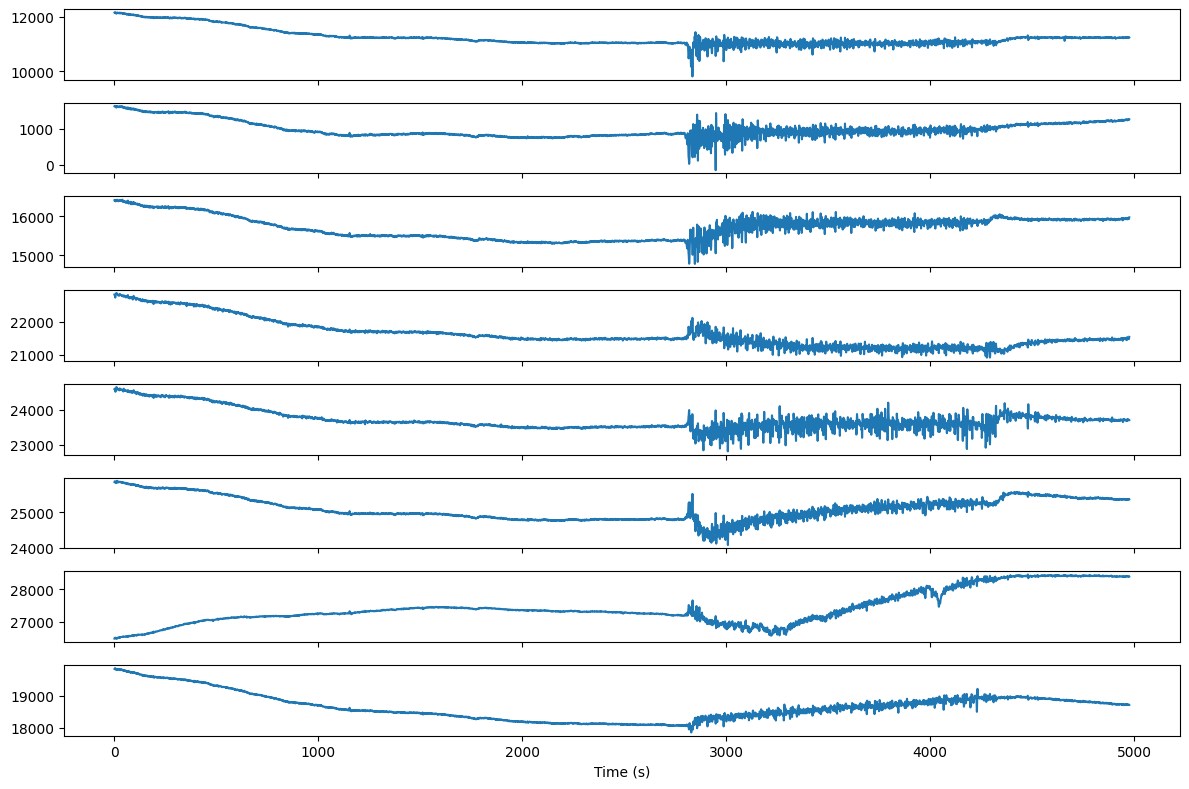

In [73]:
fig, axes = plt.subplots(
    emg_channels.shape[1],
    1,
    figsize=(12, 8),
    sharex=True
)

for i in range(8):
    axes[i].plot(emg_channels[:, i])

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [74]:
time.shape
filtered_emg_channels.shape

(4977, 8)

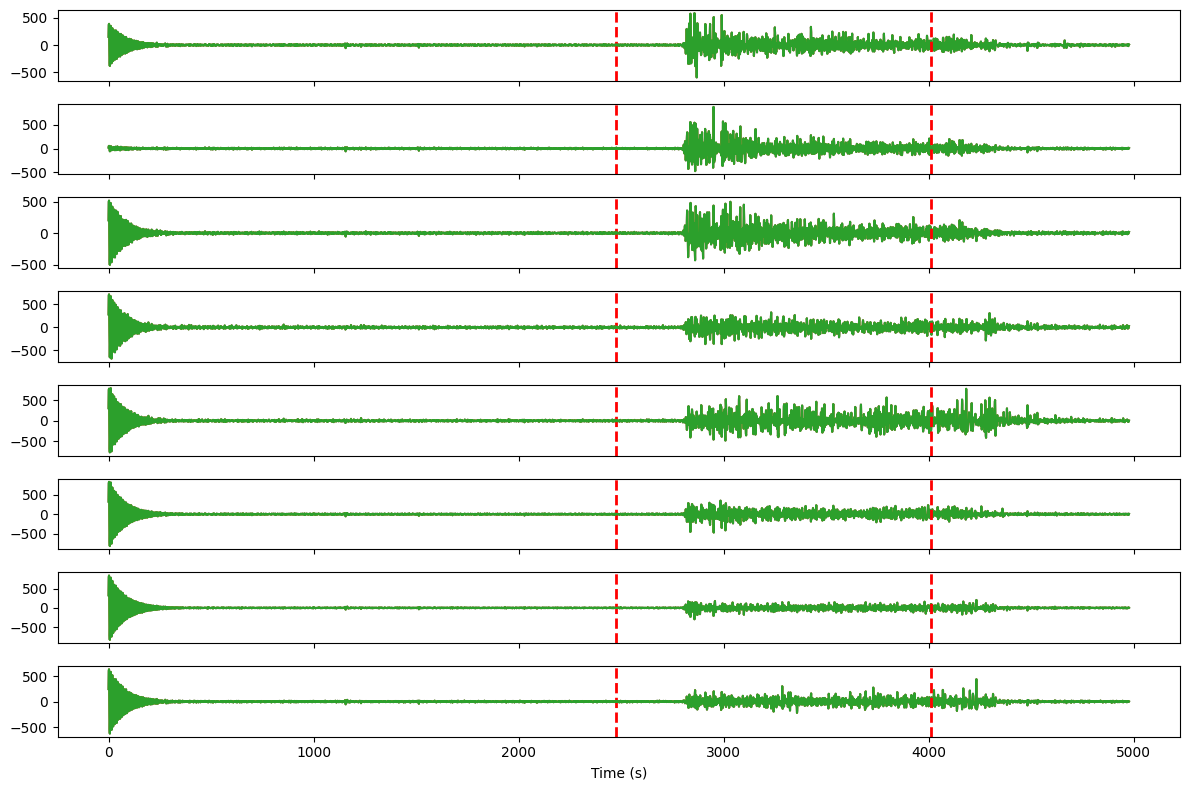

In [82]:
# Create one plot per EMG channel
fig, axes = plt.subplots(
    filtered_emg_channels.shape[1],
    1,
    figsize=(12, 8),
    sharex=True
)
    
for i in range(8):
    axes[i].plot(filtered_emg_channels[:, i])


x_value = np.where(marker_channels == 1)[0]  # x position where you want the vertical line

for i in range(8):
    axes[i].plot(filtered_emg_channels[:, i])
    axes[i].axvline(x=x_value, color='red', linestyle='--', linewidth=2)

x_value = np.where(marker_channels == -1)[0]  # x position where you want the vertical line

for i in range(8):
    axes[i].plot(filtered_emg_channels[:, i])
    axes[i].axvline(x=x_value, color='red', linestyle='--', linewidth=2)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [78]:
arr = [1, 2, 2, 3, 4, 4, 5]

unique = list(set(marker_channels))

print(unique)

[np.float64(0.0), np.float64(1.0), np.float64(-1.0)]


In [80]:
np.where(marker_channels == 1)

(array([2476]),)